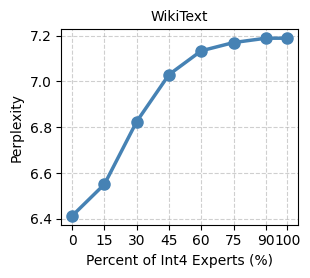

In [6]:
import matplotlib.pyplot as plt

# 数据
x = [0, 15, 30, 45, 60, 75, 90, 100]
y = [6.413, 6.551, 6.825, 7.03, 7.134, 7.17, 7.189, 7.189]

# 绘制折线图
plt.figure(figsize=(6.4*0.5, 4.8*0.6))
plt.plot(x, y, marker='o', linewidth=2.5, markersize=8, color='steelblue')

# 设置标题和标签
plt.title("WikiText", fontsize=10)
plt.xlabel("Percent of Int4 Experts (%)", fontsize=10)
plt.ylabel("Perplexity", fontsize=10)

# 设置坐标轴刻度与网格
plt.xticks(x)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示数值标注
# for i, val in enumerate(y):
#     plt.text(x[i], val + 0.05, f"{val:.2f}", ha='center', fontsize=10)

# 美化边框
plt.tight_layout()
plt.savefig("wiki_ppl_qwen30b.pdf", format="pdf")


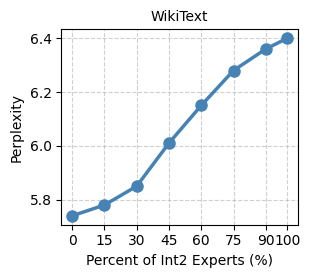

In [50]:
import matplotlib.pyplot as plt

# 数据
x = [0, 15, 30, 45, 60, 75, 90, 100]
y = [5.74, 5.78, 5.85, 6.01, 6.15, 6.28, 6.36, 6.40]

# 绘制折线图
plt.figure(figsize=(6.4*0.5, 4.8*0.6))
plt.plot(x, y, marker='o', linewidth=2.5, markersize=8, color='steelblue')

# 设置标题和标签
plt.title("WikiText", fontsize=10)
plt.xlabel("Percent of Int2 Experts (%)", fontsize=10)
plt.ylabel("Perplexity", fontsize=10)

# 设置坐标轴刻度与网格
plt.xticks(x)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示数值标注
# for i, val in enumerate(y):
#     plt.text(x[i], val + 0.05, f"{val:.2f}", ha='center', fontsize=10)

# 美化边框
plt.tight_layout()
plt.savefig("wiki_ppl_qwen80b.pdf", format="pdf")


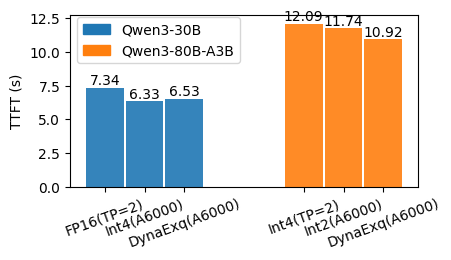

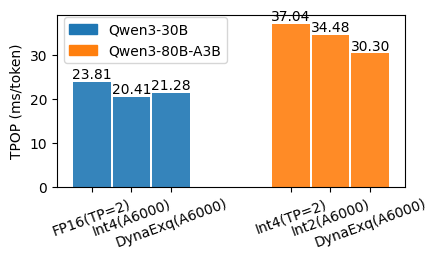

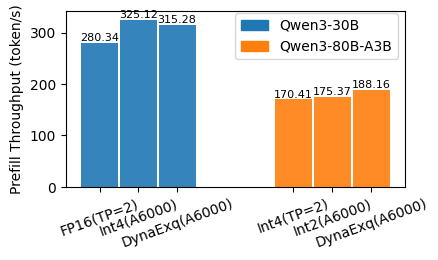

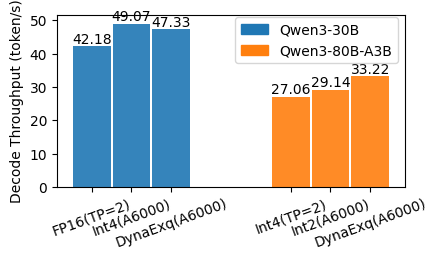

In [49]:
import numpy as np
import matplotlib.pyplot as plt

model_data = {
    "Qwen3-30B": {
        "FP16(TP=2)": {"ttft": 7.34, "tpop": 23.81, "prefill": 280.34, "decode": 42.18},
        "Int4(A6000)": {"ttft": 6.33, "tpop": 20.41, "prefill": 325.12, "decode": 49.07},
        "DynaExq(A6000)": {"ttft": 6.53, "tpop": 21.28, "prefill": 315.28, "decode": 47.33},
        # "DynaExq(5090)": {"ttft": 6.13, "tpop": 19.61, "prefill": 335.19, "decode": 51.24},
    },
    "Qwen3-80B-A3B": {
        "Int4(TP=2)": {"ttft": 12.09, "tpop": 37.04, "prefill": 170.41, "decode": 27.06},
        "Int2(A6000)": {"ttft": 11.74, "tpop": 34.48, "prefill": 175.37, "decode": 29.14},
        "DynaExq(A6000)": {"ttft": 10.92, "tpop": 30.30, "prefill": 188.16, "decode": 33.22},
        # "DynaExq(5090)": {"ttft": 9.01, "tpop": 27.03, "prefill": 228.11, "decode": 37.18},
    },
}

metrics = [
    ("TTFT (s)", "ttft"),
    ("TPOP (ms/token)", "tpop"),
    ("Prefill Throughput (token/s)", "prefill"),
    ("Decode Throughput (token/s)", "decode"),
]

model_colors = {"Qwen3-30B": "#1f77b4", "Qwen3-80B-A3B": "#ff7f0e"}

for title, key in metrics:
    fig, ax = plt.subplots(figsize=(6.4*0.7, 4.8*0.56))
    model_names = list(model_data.keys())
    width = 0.2
    group_spacing = 0.4
    configs_per_model = {name: list(configs.keys()) for name, configs in model_data.items()}

    xtick_positions = []
    xtick_labels = []

    cursor = 0.0
    for idx, model in enumerate(model_names):
        configs = configs_per_model[model]
        positions = cursor + np.arange(len(configs)) * width
        values = [model_data[model][config][key] for config in configs]
        bars = ax.bar(positions, values, width=width * 0.95, color=model_colors[model], alpha=0.9)

        for j, (bar, value, label) in enumerate(zip(bars, values, configs)):
            center = bar.get_x() + bar.get_width() / 2
            if "Prefill" in title:
                ax.text(center, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
            else:
                ax.text(center, value, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

            xtick_positions.append(center)
            xtick_labels.append(f"{label}")

        cursor = positions[-1] + width + group_spacing

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=20, ha="center", fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    # ax.grid(axis="y", linestyle="--", alpha=0.3)

    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in model_colors.values()]
    if "TTFT" in title or "TPOP" in title:
        ax.legend(handles, model_colors.keys(), loc="upper left", fontsize=10, bbox_to_anchor=(0.0, 1.03))
    else:
        ax.legend(handles, model_colors.keys(), loc="upper right", fontsize=10, bbox_to_anchor=(1.0, 1.03))

    fig.tight_layout()
    fig.savefig(f"{title.split(' (')[0].replace(' ', '_').replace('/', '_').lower()}_comparison.pdf", format="pdf")
    plt.show()
